In [23]:
import pymysql
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
try:
    conn = pymysql.connect(
        host='212.227.90.6',
        user='Equipo21',
        password= 'E1q2u3i4p5o21',
        database='Equip_21',
    )
    print("✅ Conexión establecida con PyMySQL")
except Exception as e:
    print("❌ Error:", e)

✅ Conexión establecida con PyMySQL


In [25]:
query= "SHOW TABLES"

df=pd.read_sql(query,conn)

df

C:\Users\GPSantana\AppData\Local\Temp\ipykernel_11392\3889364871.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,conn)


,Tables_in_Equip_21
0,BANK_marketing


In [26]:
query = "SELECT * FROM BANK_marketing"

df = pd.read_sql(query, conn)

conn.close()

C:\Users\GPSantana\AppData\Local\Temp\ipykernel_11392\4031327985.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [27]:
df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,2,59.0,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
2,3,56.0,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
3,4,41.0,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
4,5,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes


In [28]:
df["campaign_group"] = pd.cut(
    df["campaign"],
    bins=[0, 1, 2, 3, df["campaign"].max()],
    labels=["1", "2", "3", "4+"]
)

In [31]:
df["deposit"] = df["deposit"].map({"yes": 1, "no": 0})

In [43]:
summary = (
    df
    .groupby("campaign_group")
    .agg(
        total_clients=("deposit", "count"),
        success=("deposit", "sum"),
        success_rate=("deposit", "mean")
    )
    .reset_index()
)

summary["success_rate_pct"] = summary["success_rate"] * 100

C:\Users\GPSantana\AppData\Local\Temp\ipykernel_11392\1670148123.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("campaign_group")


In [33]:
summary

,campaign_group,total_clients,success,success_rate
0,1,4593,2562,0.557805
1,2,2885,1401,0.485615
2,3,1256,618,0.492038
3,4+,1909,709,0.371399


Para el análisis, la variable campaign se discretizó en grupos con el objetivo de garantizar la estabilidad estadística y facilitar la interpretación de los resultados.
Los valores más altos se agruparon en una única categoría debido al bajo número de observaciones.

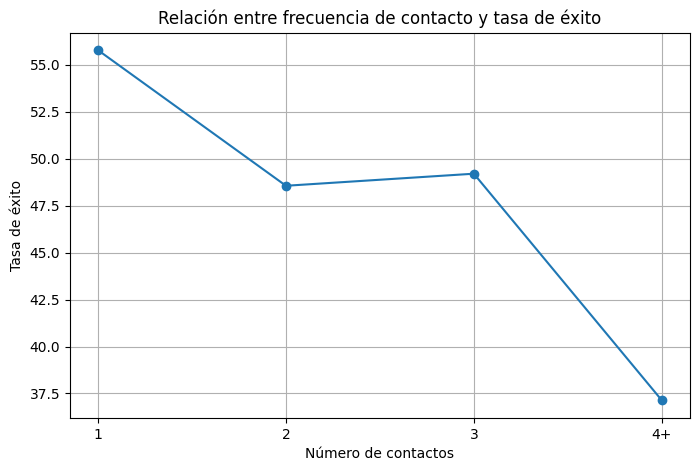

In [44]:
plt.figure(figsize=(8,5))
plt.plot(summary["campaign_group"], summary["success_rate"] * 100, marker="o")
plt.xlabel("Número de contactos")
plt.ylabel("Tasa de éxito")
plt.title("Relación entre frecuencia de contacto y tasa de éxito")
plt.grid(True)
plt.show()

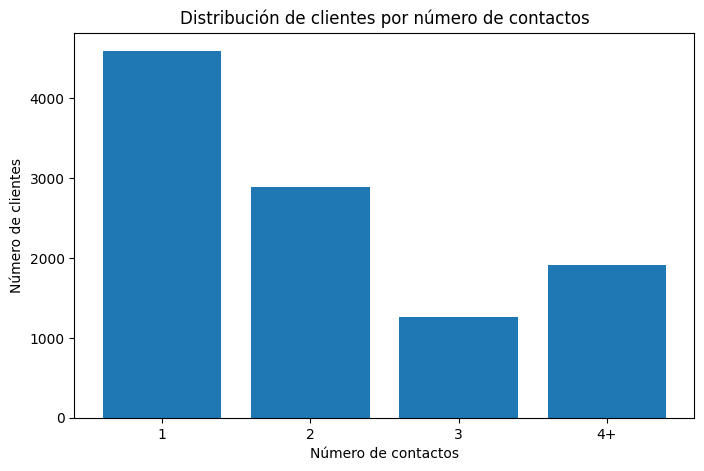

In [72]:
plt.figure(figsize=(8,5))
plt.bar(summary["campaign_group"], summary["total_clients"])
plt.xlabel("Número de contactos")
plt.ylabel("Número de clientes")
plt.title("Distribución de clientes por número de contactos")
plt.show()

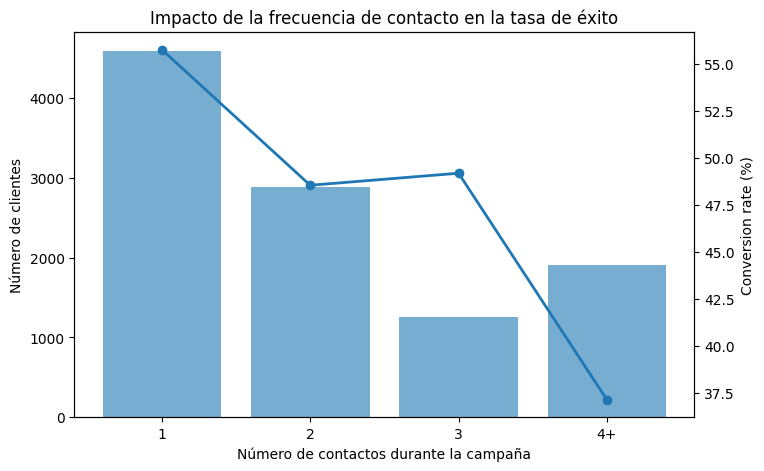

In [47]:
fig, ax1 = plt.subplots(figsize=(8, 5))

# Barchart 
ax1.bar(
    summary["campaign_group"],
    summary["total_clients"],
    alpha=0.6
)
ax1.set_xlabel("Número de contactos durante la campaña")
ax1.set_ylabel("Número de clientes")

# Y: conversion rate
ax2 = ax1.twinx()
ax2.plot(
    summary["campaign_group"],
    summary["success_rate_pct"],
    marker="o",
    linewidth=2
)
ax2.set_ylabel("Conversion rate (%)")

plt.title("Impacto de la frecuencia de contacto en la tasa de éxito")
plt.show()

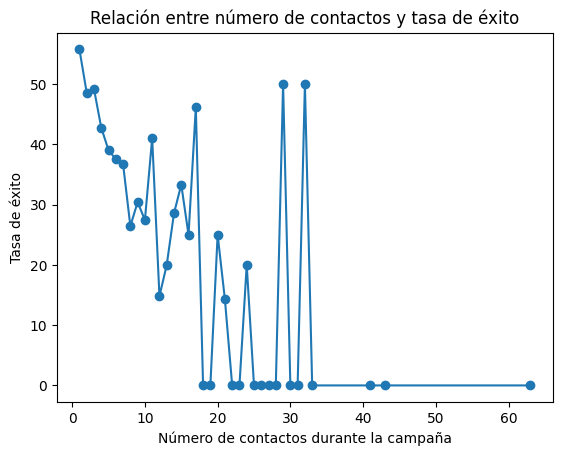

In [73]:
plt.figure()
plt.plot(success_by_campaign['campaign'],
         success_by_campaign['success_rate'] *100,
         marker='o')

plt.xlabel('Número de contactos durante la campaña')
plt.ylabel('Tasa de éxito')
plt.title('Relación entre número de contactos y tasa de éxito')
plt.show()

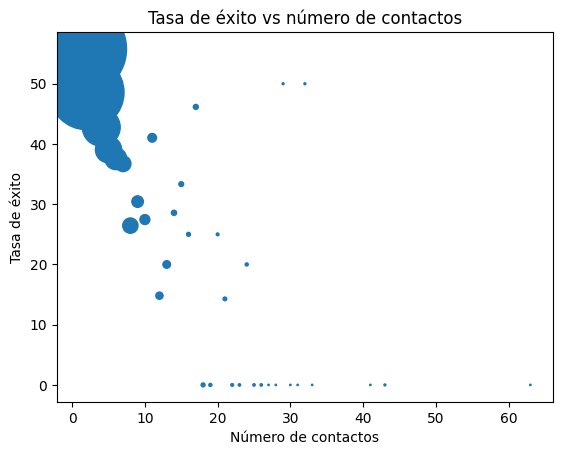

In [74]:
plt.figure()
plt.scatter(
    campaign_stats['campaign'],
    campaign_stats['success_rate'] * 100,
    s=campaign_stats['n_clients']
)

plt.xlabel('Número de contactos')
plt.ylabel('Tasa de éxito')
plt.title('Tasa de éxito vs número de contactos')
plt.show()


Segmentación por grupos de edad

In [75]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 30, 45, 60, 100],
    labels=['Jóvenes', 'Adultos', 'Senior', 'Mayores']
)


In [57]:
age_campaign = (
    df.groupby(['age_group', 'campaign'])['deposit']
      .mean()
      .reset_index()
)

age_campaign


C:\Users\GPSantana\AppData\Local\Temp\ipykernel_11392\4042841208.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['age_group', 'campaign'])['deposit']


,age_group,campaign,deposit
0,Jóvenes,1,0.639868
1,Jóvenes,2,0.584762
2,Jóvenes,3,0.587379
3,Jóvenes,4,0.475000
4,Jóvenes,5,0.469697
...,...,...,...
139,Mayores,32,NaN
140,Mayores,33,NaN
141,Mayores,41,NaN
142,Mayores,43,NaN


Segmentación por profesión.

In [59]:
job_campaign = (
    df.groupby(['job', 'campaign'])['deposit']
      .mean()
      .reset_index()
)


In [60]:
top_jobs = df['job'].value_counts().head(5).index
job_campaign[job_campaign['job'].isin(top_jobs)]


,job,campaign,deposit
0,admin.,1,0.546624
1,admin.,2,0.500000
2,admin.,3,0.421429
3,admin.,4,0.486842
4,admin.,5,0.228571
...,...,...,...
176,technician,23,0.000000
177,technician,24,0.000000
178,technician,25,0.000000
179,technician,26,0.000000


Segmentación por capacidad economica

In [61]:
df['balance_group'] = pd.qcut(
    df['balance'],
    q=3,
    labels=['Bajo', 'Medio', 'Alto']
)


In [62]:
balance_campaign = (
    df.groupby(['balance_group', 'campaign'])['deposit']
      .mean()
      .reset_index()
)

balance_campaign


C:\Users\GPSantana\AppData\Local\Temp\ipykernel_11392\1966506800.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['balance_group', 'campaign'])['deposit']


,balance_group,campaign,deposit
0,Bajo,1,0.455533
1,Bajo,2,0.395918
2,Bajo,3,0.407407
3,Bajo,4,0.333333
4,Bajo,5,0.330435
...,...,...,...
103,Alto,32,0.000000
104,Alto,33,NaN
105,Alto,41,NaN
106,Alto,43,NaN


In [66]:
summary_segmentacion = (
    df.groupby(['age_group', 'balance_group'])
      .agg(
          success_rate=('deposit', 'mean'),
          avg_contacts=('campaign', 'mean')
      )
      .reset_index()
)

summary_segmentacion


C:\Users\GPSantana\AppData\Local\Temp\ipykernel_11392\3421428823.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['age_group', 'balance_group'])


,age_group,balance_group,success_rate,avg_contacts
0,Jóvenes,Bajo,0.492816,2.527299
1,Jóvenes,Medio,0.628611,2.189821
2,Jóvenes,Alto,0.674510,2.147059
3,Adultos,Bajo,0.372654,2.712601
4,Adultos,Medio,0.445281,2.549508
5,Adultos,Alto,0.537897,2.466993
6,Senior,Bajo,0.348655,2.660314
7,Senior,Medio,0.453846,2.665934
8,Senior,Alto,0.538028,2.484507
9,Mayores,Bajo,0.822917,1.729167


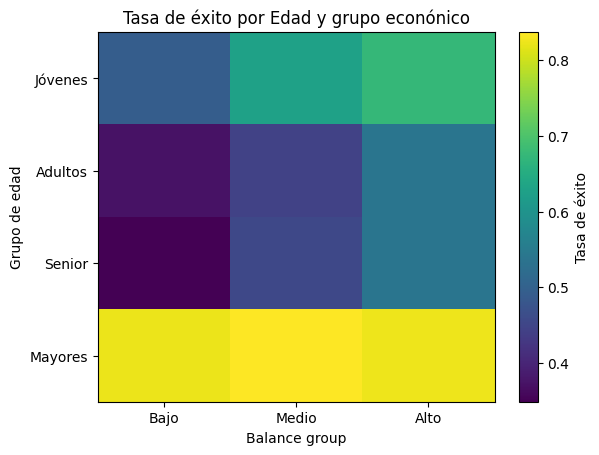

In [70]:
pivot_sr = summary_segmentacion.pivot(
    index='age_group',
    columns='balance_group',
    values='success_rate'
)

plt.figure()
plt.imshow(pivot_sr, aspect='auto')
plt.colorbar(label='Tasa de éxito')
plt.xticks(range(len(pivot_sr.columns)), pivot_sr.columns)
plt.yticks(range(len(pivot_sr.index)), pivot_sr.index)
plt.xlabel('Balance group')
plt.ylabel('Grupo de edad')
plt.title('Tasa de éxito por Edad y grupo econónico')
plt.show()

El análisis muestra que la tasa de éxito de la campaña es significativamente mayor cuando el número de contactos realizados es bajo, especialmente en el primer y segundo contacto. A medida que aumenta el número de intentos, la probabilidad de éxito disminuye de forma progresiva, lo que sugiere que los clientes contactados repetidamente presentan una menor predisposición a contratar el producto.

Este patrón indica que el número de contactos funciona como un indicador del interés del cliente: aquellos con mayor intención de conversión responden en etapas tempranas, mientras que los contactos reiterados generan un bajo retorno.

Para optimizar la estrategia de marketing, se recomienda establecer un límite máximo de contactos por cliente, aplicar estrategias de early stopping tras varios intentos fallidos y redistribuir los recursos hacia segmentos con mayor probabilidad de conversión temprana. De este modo, se mejora la eficiencia de la campaña y se reduce el coste por adquisición.

El análisis segmentado muestra que la relación entre número de contactos y tasa de éxito no es homogénea entre los distintos perfiles de clientes. Los clientes de mayor edad, con mayor capacidad económica y profesiones cualificadas presentan tasas de conversión elevadas en los primeros contactos, mientras que insistir en segmentos con menor balance o menor predisposición no incrementa significativamente la probabilidad de éxito.

Estos resultados sugieren que una estrategia de marketing basada en segmentación permite optimizar la frecuencia de contacto, reducir costes operativos y maximizar el retorno de la campaña, priorizando los contactos tempranos en los segmentos con mayor probabilidad de conversión.